In [1]:
import pandas as pd
import numpy as np

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 2.3.3
numpy version: 2.0.2


In [2]:
import numpy as np

def gini_coefficient(incomes):
    incomes = np.array(incomes)
    n = len(incomes)
    mean_income = np.mean(incomes)
    
    # sum of |x_i - x_j| over all pairs
    total_diff = 0
    for i in range(n):
        for j in range(n):
            total_diff += abs(incomes[i] - incomes[j])
    
    gini = total_diff / (2 * n**2 * mean_income)
    return gini

    # everyone has the same income -> should print 0.0
print(gini_coefficient([50, 50, 50, 50]))

# one person has everything, rest have nothing 
# should print a number close to 1
print(gini_coefficient([1, 1, 1, 1000]))

# mixed example
print(gini_coefficient([50, 50, 70, 70, 70, 90, 150, 150, 150, 150]))

0.0
0.7470089730807578
0.226


In [3]:
def spectral_gap(transition_matrix):
    matrix = np.array(transition_matrix)
    eigenvalues = np.linalg.eigvals(matrix)
    
    # sort eigenvalues by absolute value, descending
    sorted_eigs = sorted(eigenvalues, key=abs, reverse=True)
    
    largest = sorted_eigs[0]
    second_largest = sorted_eigs[1]
    
    gap = 1 - abs(second_largest)
    return gap, second_largest

sticky_matrix = [
    [0.6, 0.3, 0.1],
    [0.2, 0.6, 0.2],
    [0.1, 0.3, 0.6]
]

gap, second_eig = spectral_gap(sticky_matrix)
print("Second eigenvalue:", second_eig)
print("Spectral gap:", gap)

mobile_matrix = [
    [0.34, 0.33, 0.33],
    [0.33, 0.34, 0.33],
    [0.33, 0.33, 0.34]
]

gap2, second_eig2 = spectral_gap(mobile_matrix)
print("Second eigenvalue:", second_eig2)
print("Spectral gap:", gap2)

Second eigenvalue: 0.4999999999999997
Spectral gap: 0.5000000000000002
Second eigenvalue: 0.010000000000000004
Spectral gap: 0.99


In [4]:
def simulate_population(transition_matrix, initial_distribution, generations, income_values):
    matrix = np.array(transition_matrix)
    distribution = np.array(initial_distribution) 
    
    history = []
    for gen in range(generations):
        # distribution is fraction of population in each group
        history.append(distribution.copy())
        distribution = distribution @ matrix  # one generation's transition
    
    return history

initial = [1.0, 0.0, 0.0]  # everyone starts in low income
history = simulate_population(sticky_matrix, initial, generations=10, income_values=[30, 60, 120])

for i, dist in enumerate(history):
    print(f"Generation {i}: {dist}")

Generation 0: [1. 0. 0.]
Generation 1: [0.6 0.3 0.1]
Generation 2: [0.43 0.39 0.18]
Generation 3: [0.354 0.417 0.229]
Generation 4: [0.3187 0.4251 0.2562]
Generation 5: [0.30186 0.42753 0.27061]
Generation 6: [0.293683 0.428259 0.278058]
Generation 7: [0.2896674 0.4284777 0.2818549]
Generation 8: [0.28768147 0.42854331 0.28377522]
Generation 9: [0.28669507 0.42856299 0.28474194]


In [5]:
def distribution_to_incomes(distribution, income_values, population_size=10000):
    incomes = []
    for fraction, income in zip(distribution, income_values):
        count = int(round(fraction * population_size))
        incomes.extend([income] * count)
    return incomes

In [6]:
final_distribution = history[-1]  # last generation 
income_values = [30, 60, 120]

incomes = distribution_to_incomes(final_distribution, income_values)
steady_state_gini = gini_coefficient(incomes)

print("Steady-state distribution:", final_distribution)
print("Steady-state Gini coefficient:", steady_state_gini)

Steady-state distribution: [0.28669507 0.42856299 0.28474194]
Steady-state Gini coefficient: 0.2680137249748106


In [7]:
history_mobile = simulate_population(mobile_matrix, initial, generations=20, income_values=[30, 60, 120])
final_dist_mobile = history_mobile[-1]

incomes_mobile = distribution_to_incomes(final_dist_mobile, income_values)
gini_mobile = gini_coefficient(incomes_mobile)

print("Mobile matrix steady-state distribution:", final_dist_mobile)
print("Mobile matrix Gini:", gini_mobile)
print("Mobile matrix spectral gap:", spectral_gap(mobile_matrix)[0])
print("---")
print("Sticky matrix Gini:", steady_state_gini)
print("Sticky matrix spectral gap:", spectral_gap(sticky_matrix)[0])

Mobile matrix steady-state distribution: [0.33333333 0.33333333 0.33333333]
Mobile matrix Gini: 0.2857142857142857
Mobile matrix spectral gap: 0.99
---
Sticky matrix Gini: 0.2680137249748106
Sticky matrix spectral gap: 0.5000000000000002


In [8]:
def random_transition_matrix(size=3):
    matrix = np.random.rand(size, size)
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix = matrix / row_sums
    return matrix

In [9]:
test_matrix = random_transition_matrix()
print(test_matrix)
print("Row sums:", test_matrix.sum(axis=1))

[[0.35878322 0.32021039 0.32100639]
 [0.6313544  0.29466176 0.07398383]
 [0.30014917 0.33156249 0.36828834]]
Row sums: [1. 1. 1.]


In [10]:
def gini_coefficient(incomes):
    incomes = np.sort(np.array(incomes))
    n = len(incomes)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * incomes) - (n + 1) * np.sum(incomes)) / (n * np.sum(incomes))

In [11]:
print(gini_coefficient([50, 50, 50, 50]))
print(gini_coefficient([1, 1, 1, 1000]))
print(gini_coefficient([50, 50, 70, 70, 70, 90, 150, 150, 150, 150]))

0.0
0.7470089730807578
0.226


In [12]:
spectral_gaps = []
gini_values = []

for i in range(50):
    matrix = random_transition_matrix(size=3)
    gap, _ = spectral_gap(matrix)
    
    initial = [1.0, 0.0, 0.0]
    history = simulate_population(matrix, initial, generations=100, income_values=[30, 60, 120])
    final_dist = history[-1]
    
    incomes = distribution_to_incomes(final_dist, income_values=[30, 60, 120])
    g = gini_coefficient(incomes)
    
    spectral_gaps.append(gap)
    gini_values.append(g)

print("Generated", len(spectral_gaps), "matrices")
print("First few spectral gaps:", spectral_gaps[:5])
print("First few Gini values:", gini_values[:5])

Generated 50 matrices
First few spectral gaps: [np.float64(0.7701033939966115), np.float64(0.6856322819132451), np.float64(0.6214221632693708), np.float64(0.9082625979863905), np.float64(0.967330906652572)]
First few Gini values: [np.float64(0.2946270385267261), np.float64(0.2774623418865197), np.float64(0.27758239134027435), np.float64(0.24193318082952073), np.float64(0.3242252401582219)]


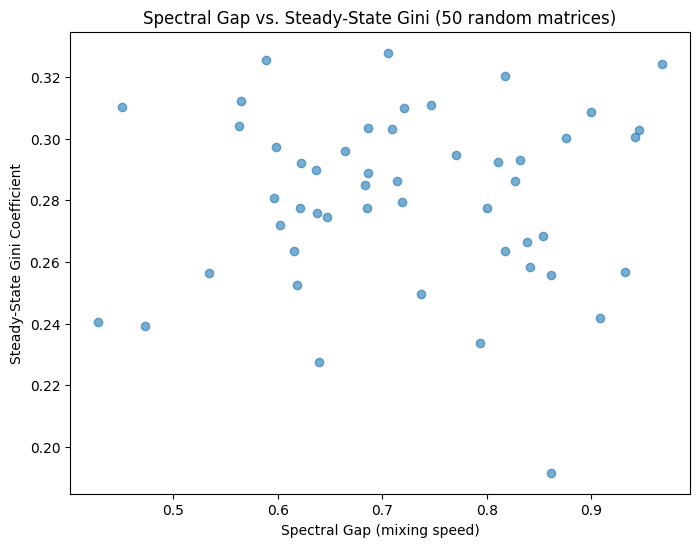

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(spectral_gaps, gini_values, alpha=0.6)
plt.xlabel("Spectral Gap (mixing speed)")
plt.ylabel("Steady-State Gini Coefficient")
plt.title("Spectral Gap vs. Steady-State Gini (50 random matrices)")
plt.show()

In [14]:
!pip install matplotlib

In [15]:
spectral_gaps = []
gini_values = []
matrices = []

for i in range(50):
    matrix = random_transition_matrix(size=3)
    gap, _ = spectral_gap(matrix)
    
    initial = [1.0, 0.0, 0.0]
    history = simulate_population(matrix, initial, generations=100, income_values=[30, 60, 120])
    final_dist = history[-1]
    
    incomes = distribution_to_incomes(final_dist, income_values=[30, 60, 120])
    g = gini_coefficient(incomes)
    
    spectral_gaps.append(gap)
    gini_values.append(g)
    matrices.append(matrix)

print("Generated", len(spectral_gaps), "matrices")

Generated 50 matrices


In [16]:
import numpy as np

gini_array = np.array(gini_values)

min_idx = np.argmin(gini_array)
max_idx = np.argmax(gini_array)

print("Lowest Gini:", gini_array[min_idx], "at spectral gap:", spectral_gaps[min_idx])
print("Matrix with lowest Gini:")
print(matrices[min_idx])
print()
print("Highest Gini:", gini_array[max_idx], "at spectral gap:", spectral_gaps[max_idx])
print("Matrix with highest Gini:")
print(matrices[max_idx])

Lowest Gini: 0.08663759894095259 at spectral gap: 0.6925627908886937
Matrix with lowest Gini:
[[0.1073563  0.54331862 0.34932508]
 [0.12074499 0.20474313 0.67451188]
 [0.01230813 0.1156536  0.87203827]]

Highest Gini: 0.32901485620856574 at spectral gap: 0.6130081377096608
Matrix with highest Gini:
[[0.50523986 0.08103675 0.41372339]
 [0.50516282 0.44596468 0.04887249]
 [0.73694079 0.04575562 0.21730359]]


In [17]:
initial = [1.0, 0.0, 0.0]

low_gini_history = simulate_population(matrices[min_idx], initial, generations=100, income_values=[30, 60, 120])
high_gini_history = simulate_population(matrices[max_idx], initial, generations=100, income_values=[30, 60, 120])

print("Low-Gini matrix steady state:", low_gini_history[-1])
print("High-Gini matrix steady state:", high_gini_history[-1])

Low-Gini matrix steady state: [0.03053223 0.14129947 0.82816829]
High-Gini matrix steady state: [0.57756314 0.11025958 0.31217728]


In [18]:
def distribution_entropy(distribution):
    """
    Computes entropy of a distribution - measures how spread out it is.
    High entropy = spread evenly across groups.
    Low entropy = concentrated in one group.
    """
    distribution = np.array(distribution)
    # avoid log(0) issues by filtering out zero entries
    nonzero = distribution[distribution > 0]
    return -np.sum(nonzero * np.log(nonzero))

In [19]:
# perfectly spread out across 3 groups -> should be HIGH entropy
print(distribution_entropy([1/3, 1/3, 1/3]))

# perfectly concentrated in one group -> should be 0 (LOWEST possible entropy)
print(distribution_entropy([1.0, 0.0, 0.0]))

# somewhere in between
print(distribution_entropy([0.6, 0.3, 0.1]))

1.0986122886681096
-0.0
0.8979457248567797


In [20]:
entropy_values = []

for matrix in matrices:
    history = simulate_population(matrix, initial, generations=100, income_values=[30, 60, 120])
    final_dist = history[-1]
    ent = distribution_entropy(final_dist)
    entropy_values.append(ent)

print("Computed", len(entropy_values), "entropy values")
print("First few:", entropy_values[:5])

Computed 50 entropy values
First few: [np.float64(1.0623843649905662), np.float64(1.0646492802993688), np.float64(1.0822783034541819), np.float64(1.0671296465571045), np.float64(0.9314117535471884)]


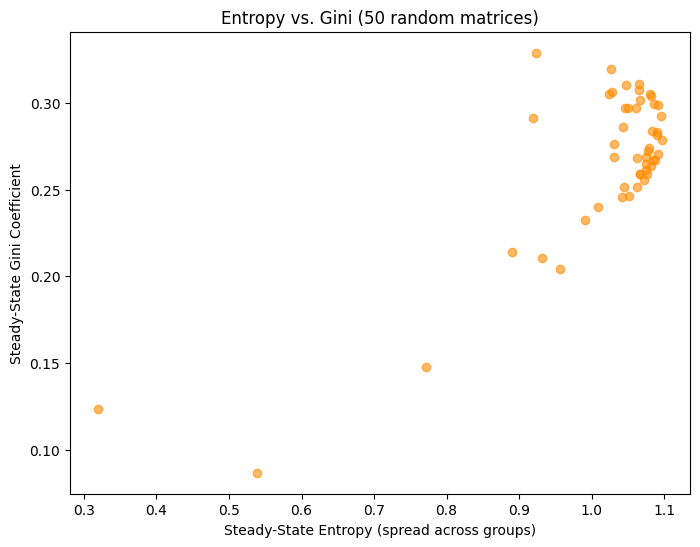

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(entropy_values, gini_values, alpha=0.6, color='darkorange')
plt.xlabel("Steady-State Entropy (spread across groups)")
plt.ylabel("Steady-State Gini Coefficient")
plt.title("Entropy vs. Gini (50 random matrices)")
plt.show()

In [22]:
!pip install scikit-learn

In [23]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.column_stack([spectral_gaps, entropy_values])  # two features
y = np.array(gini_values)

model = LinearRegression()
model.fit(X, y)

print("Coefficient for spectral gap:", model.coef_[0])
print("Coefficient for entropy:", model.coef_[1])
print("Intercept:", model.intercept_)
print("R² score:", model.score(X, y))

Coefficient for spectral gap: -0.022607589720626108
Coefficient for entropy: 0.2719636438352772
Intercept: 0.004153770346388752
R² score: 0.6169091377259017


In [24]:
def run_experiment(income_values, n_matrices=50, generations=100):

    sg_list = []
    ent_list = []
    gini_list = []
    
    initial = [1.0, 0.0, 0.0] + [0.0] * (len(income_values) - 3) if len(income_values) > 3 else [1.0, 0.0, 0.0]
    
    for i in range(n_matrices):
        matrix = random_transition_matrix(size=len(income_values))
        gap, _ = spectral_gap(matrix)
        
        history = simulate_population(matrix, initial, generations=generations, income_values=income_values)
        final_dist = history[-1]
        
        ent = distribution_entropy(final_dist)
        
        incomes = distribution_to_incomes(final_dist, income_values=income_values)
        g = gini_coefficient(incomes)
        
        sg_list.append(gap)
        ent_list.append(ent)
        gini_list.append(g)
    
    return sg_list, ent_list, gini_list

In [25]:
# Original spacing (uneven: 30, 60, 120)
sg1, ent1, gini1 = run_experiment([30, 60, 120])

# Evenly spaced
sg2, ent2, gini2 = run_experiment([30, 60, 90])

# More extreme spacing
sg3, ent3, gini3 = run_experiment([30, 60, 300])

print("Done running all three experiments")

Done running all three experiments


In [26]:
from sklearn.linear_model import LinearRegression

def check_entropy_gini_relationship(entropy_list, gini_list, label):
    X = np.array(entropy_list).reshape(-1, 1)
    y = np.array(gini_list)
    
    model = LinearRegression()
    model.fit(X, y)
    
    print(f"--- {label} ---")
    print("Entropy coefficient:", model.coef_[0])
    print("R² score:", model.score(X, y))
    print()

check_entropy_gini_relationship(ent1, gini1, "Uneven spacing: 30, 60, 120")
check_entropy_gini_relationship(ent2, gini2, "Even spacing: 30, 60, 90")
check_entropy_gini_relationship(ent3, gini3, "Extreme spacing: 30, 60, 300")

--- Uneven spacing: 30, 60, 120 ---
Entropy coefficient: 0.18484044231855656
R² score: 0.21193698047558163

--- Even spacing: 30, 60, 90 ---
Entropy coefficient: 0.30536523389916576
R² score: 0.4173042912979025

--- Extreme spacing: 30, 60, 300 ---
Entropy coefficient: 0.5760016486022037
R² score: 0.5929892059897732



In [27]:
def repeated_trials(income_values, n_trials=5, n_matrices=50):
   
    r2_scores = []
    
    for trial in range(n_trials):
        sg, ent, gini = run_experiment(income_values, n_matrices=n_matrices)
        
        X = np.array(ent).reshape(-1, 1)
        y = np.array(gini)
        model = LinearRegression()
        model.fit(X, y)
        
        r2_scores.append(model.score(X, y))
    
    return r2_scores

In [28]:
r2_uneven = repeated_trials([30, 60, 120])
r2_even = repeated_trials([30, 60, 90])
r2_extreme = repeated_trials([30, 60, 300])

print("Uneven (30,60,120) R² across trials:", r2_uneven)
print("Mean:", np.mean(r2_uneven), "Std:", np.std(r2_uneven))
print()
print("Even (30,60,90) R² across trials:", r2_even)
print("Mean:", np.mean(r2_even), "Std:", np.std(r2_even))
print()
print("Extreme (30,60,300) R² across trials:", r2_extreme)
print("Mean:", np.mean(r2_extreme), "Std:", np.std(r2_extreme))

Uneven (30,60,120) R² across trials: [0.7382269714984422, 0.6692846959656138, 0.3133732020490798, 0.04322556638150021, 0.2311219441846737]
Mean: 0.39904647601586196 Std: 0.2646579611624615

Even (30,60,90) R² across trials: [0.195299960413848, 0.15948205066650112, 0.5243677699938871, 0.41566948225125844, 0.006861985102866064]
Mean: 0.26033624968567215 Std: 0.18573720577384767

Extreme (30,60,300) R² across trials: [0.08798517161310737, 0.7041895711442046, 0.4626549444958338, 0.005018770708353548, 0.37460346187266347]
Mean: 0.32689038396683257 Std: 0.2544563877189884


In [29]:
def conductance(transition_matrix, stationary_dist):
    matrix = np.array(transition_matrix)
    pi = np.array(stationary_dist)
    n = len(pi)
    
    min_phi = float('inf')
    
    from itertools import combinations
    for size in range(1, n):
        for S in combinations(range(n), size):
            S = set(S)
            S_complement = set(range(n)) - S
            
            flow = sum(pi[i] * matrix[i][j] for i in S for j in S_complement)
            
            pi_S = sum(pi[i] for i in S)
            pi_S_comp = sum(pi[i] for i in S_complement)
            
            denom = min(pi_S, pi_S_comp)
            if denom > 0:
                phi = flow / denom
                min_phi = min(min_phi, phi)
    
    return min_phi

In [30]:
initial = [1.0, 0.0, 0.0]
history = simulate_population(sticky_matrix, initial, generations=100, income_values=[30, 60, 120])
stationary = history[-1]

phi = conductance(sticky_matrix, stationary)
gap = spectral_gap(sticky_matrix)[0]

print("Stationary distribution:", stationary)
print("Conductance:", phi)
print("Spectral gap:", gap)
print()
print("Cheeger bound check: gap/2 =", gap/2, "should be <= conductance <=", (2*gap)**0.5)

Stationary distribution: [0.28571429 0.42857143 0.28571429]
Conductance: 0.3999999999999999
Spectral gap: 0.5000000000000002

Cheeger bound check: gap/2 = 0.2500000000000001 should be <= conductance <= 1.0000000000000002


In [31]:
conductance_values = []

for matrix, gini_val in zip(matrices, gini_values):
    history = simulate_population(matrix, initial, generations=100, income_values=[30, 60, 120])
    stationary = history[-1]
    phi = conductance(matrix, stationary)
    conductance_values.append(phi)

print("Computed", len(conductance_values), "conductance values")
print("First few:", conductance_values[:5])

Computed 50 conductance values
First few: [np.float64(0.5011483149059708), np.float64(0.4192668070206815), np.float64(0.6035939577524088), np.float64(0.6553655327377137), np.float64(0.6686699350017467)]


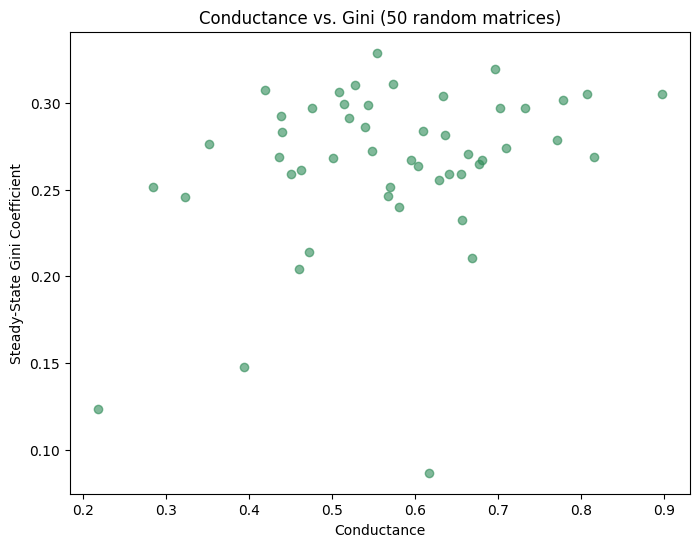

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(conductance_values, gini_values, alpha=0.6, color='seagreen')
plt.xlabel("Conductance")
plt.ylabel("Steady-State Gini Coefficient")
plt.title("Conductance vs. Gini (50 random matrices)")
plt.show()

In [33]:
X = np.column_stack([spectral_gaps, entropy_values, conductance_values])
y = np.array(gini_values)

model = LinearRegression()
model.fit(X, y)

print("Coefficient for spectral gap:", model.coef_[0])
print("Coefficient for entropy:", model.coef_[1])
print("Coefficient for conductance:", model.coef_[2])
print("Intercept:", model.intercept_)
print("R² score:", model.score(X, y))

Coefficient for spectral gap: -0.02022087410610379
Coefficient for entropy: 0.26752908542538134
Coefficient for conductance: 0.010512193542946188
Intercept: 0.0010691687613195722
R² score: 0.6177206098443642


In [35]:
def extreme_mass(distribution):

    distribution = np.array(distribution)
    return distribution[0] + distribution[-1]

In [36]:
extreme_mass_values = []

for matrix in matrices:
    history = simulate_population(matrix, initial, generations=100, income_values=[30, 60, 120])
    final_dist = history[-1]
    extreme_mass_values.append(extreme_mass(final_dist))

print("Computed", len(extreme_mass_values), "extreme mass values")
print("First few:", extreme_mass_values[:5])

Computed 50 extreme mass values
First few: [np.float64(0.5535579329766163), np.float64(0.7792981009962119), np.float64(0.603573854572721), np.float64(0.5485426953068882), np.float64(0.4534882053796593)]


In [37]:
X = np.column_stack([entropy_values, extreme_mass_values])
y = np.array(gini_values)

model = LinearRegression()
model.fit(X, y)

print("Coefficient for entropy:", model.coef_[0])
print("Coefficient for extreme mass:", model.coef_[1])
print("Intercept:", model.intercept_)
print("R² score:", model.score(X, y))

Coefficient for entropy: 0.3256084561742074
Coefficient for extreme mass: 0.16729906190583585
Intercept: -0.18006237451208718
R² score: 0.7965451158885908


In [38]:
def repeated_trials_two_features(income_values, n_trials=5, n_matrices=50):
    r2_scores = []
    
    for trial in range(n_trials):
        sg, ent, gini = run_experiment(income_values, n_matrices=n_matrices)
        
        pass
    
    return r2_scores

In [39]:
def run_full_experiment(income_values, n_matrices=50, generations=100):
    sg_list, ent_list, gini_list, extreme_list = [], [], [], []
    initial = [1.0] + [0.0]*(len(income_values)-1)
    
    for i in range(n_matrices):
        matrix = random_transition_matrix(size=len(income_values))
        gap, _ = spectral_gap(matrix)
        history = simulate_population(matrix, initial, generations=generations, income_values=income_values)
        final_dist = history[-1]
        
        ent = distribution_entropy(final_dist)
        ext = extreme_mass(final_dist)
        incomes = distribution_to_incomes(final_dist, income_values=income_values)
        g = gini_coefficient(incomes)
        
        sg_list.append(gap)
        ent_list.append(ent)
        extreme_list.append(ext)
        gini_list.append(g)
    
    return sg_list, ent_list, extreme_list, gini_list

r2_scores = []
for trial in range(5):
    sg, ent, ext, gini = run_full_experiment([30, 60, 120])
    X = np.column_stack([ent, ext])
    y = np.array(gini)
    model = LinearRegression()
    model.fit(X, y)
    r2_scores.append(model.score(X, y))

print("R² across 5 trials:", r2_scores)
print("Mean:", np.mean(r2_scores), "Std:", np.std(r2_scores))

R² across 5 trials: [0.7624099592098167, 0.5974407311043295, 0.4755239189885694, 0.6151157432827551, 0.8076355916520734]
Mean: 0.6516251888475088 Std: 0.11991085309493124


In [40]:
income_values_5 = [20, 40, 60, 90, 150]  # 5 brackets instead of 3

test_matrix_5 = random_transition_matrix(size=5)
print(test_matrix_5)
print("Row sums:", test_matrix_5.sum(axis=1))

[[0.31267994 0.15211181 0.08285257 0.14531987 0.30703581]
 [0.23033046 0.32002294 0.08126122 0.23291056 0.13547481]
 [0.35766006 0.19584332 0.1347851  0.01866168 0.29304984]
 [0.27638456 0.17541024 0.31476923 0.07025528 0.16318069]
 [0.00726774 0.20814397 0.50590767 0.12688418 0.15179643]]
Row sums: [1. 1. 1. 1. 1.]


In [41]:
sg_5, ent_5, ext_5, gini_5 = run_full_experiment(income_values_5, n_matrices=50)

print("Generated 50 5-bracket matrices")
print("First few Gini values:", gini_5[:5])

Generated 50 5-bracket matrices
First few Gini values: [np.float64(0.2872733394279744), np.float64(0.32892691034416094), np.float64(0.32101463342792425), np.float64(0.35330077526183373), np.float64(0.32837947073309864)]


In [42]:
X_5 = np.column_stack([ent_5, ext_5])
y_5 = np.array(gini_5)

model_5 = LinearRegression()
model_5.fit(X_5, y_5)

print("--- 5-bracket model ---")
print("Coefficient for entropy:", model_5.coef_[0])
print("Coefficient for extreme mass:", model_5.coef_[1])
print("R² score:", model_5.score(X_5, y_5))
print()

# also check spectral gap alone, for comparison
X_sg_5 = np.array(sg_5).reshape(-1, 1)
model_sg_5 = LinearRegression()
model_sg_5.fit(X_sg_5, y_5)
print("--- Spectral gap alone, 5-bracket ---")
print("R² score:", model_sg_5.score(X_sg_5, y_5))

--- 5-bracket model ---
Coefficient for entropy: 0.3340105066080513
Coefficient for extreme mass: 0.2600569292710942
R² score: 0.4831769693952883

--- Spectral gap alone, 5-bracket ---
R² score: 0.03299293951239035


In [43]:
def income_variance(distribution, income_values):
 
    distribution = np.array(distribution)
    income_values = np.array(income_values)
    
    mean_income = np.sum(distribution * income_values)
    variance = np.sum(distribution * (income_values - mean_income)**2)
    return variance


In [44]:
def run_full_experiment_v2(income_values, n_matrices=50, generations=100):
    sg_list, ent_list, var_list, gini_list = [], [], [], []
    initial = [1.0] + [0.0]*(len(income_values)-1)
    
    for i in range(n_matrices):
        matrix = random_transition_matrix(size=len(income_values))
        gap, _ = spectral_gap(matrix)
        history = simulate_population(matrix, initial, generations=generations, income_values=income_values)
        final_dist = history[-1]
        
        ent = distribution_entropy(final_dist)
        var = income_variance(final_dist, income_values)
        incomes = distribution_to_incomes(final_dist, income_values=income_values)
        g = gini_coefficient(incomes)
        
        sg_list.append(gap)
        ent_list.append(ent)
        var_list.append(var)
        gini_list.append(g)
    
    return sg_list, ent_list, var_list, gini_list

sg_5v2, ent_5v2, var_5v2, gini_5v2 = run_full_experiment_v2(income_values_5, n_matrices=50)

X_var5 = np.column_stack([ent_5v2, var_5v2])
y_var5 = np.array(gini_5v2)

model_var5 = LinearRegression()
model_var5.fit(X_var5, y_var5)

print("--- Entropy + Income Variance, 5-bracket ---")
print("Coefficient for entropy:", model_var5.coef_[0])
print("Coefficient for variance:", model_var5.coef_[1])
print("R² score:", model_var5.score(X_var5, y_var5))

--- Entropy + Income Variance, 5-bracket ---
Coefficient for entropy: 0.09339768023666539
Coefficient for variance: 2.1858134439049177e-05
R² score: 0.0789420111828445


In [45]:
from sklearn.preprocessing import StandardScaler

X_var5_raw = np.column_stack([ent_5v2, var_5v2])
y_var5 = np.array(gini_5v2)

scaler = StandardScaler()
X_var5_scaled = scaler.fit_transform(X_var5_raw)

model_var5_scaled = LinearRegression()
model_var5_scaled.fit(X_var5_scaled, y_var5)

print("--- Entropy + Income Variance (standardized), 5-bracket ---")
print("Coefficient for entropy:", model_var5_scaled.coef_[0])
print("Coefficient for variance:", model_var5_scaled.coef_[1])
print("R² score:", model_var5_scaled.score(X_var5_scaled, y_var5))

--- Entropy + Income Variance (standardized), 5-bracket ---
Coefficient for entropy: 0.0018323551995064588
Coefficient for variance: 0.004721650517611287
R² score: 0.0789420111828445


In [46]:
print(income_variance([0.2, 0.2, 0.2, 0.2, 0.2], income_values_5))
print(income_variance([1.0, 0, 0, 0, 0], income_values_5))

2056.0
0.0


In [47]:
r2_extreme_mass = []
r2_variance = []

for trial in range(5):
    sg, ent, ext, var, gini = [], [], [], [], []
    initial = [1.0] + [0.0]*(len(income_values_5)-1)
    
    for i in range(50):
        matrix = random_transition_matrix(size=len(income_values_5))
        gap, _ = spectral_gap(matrix)
        history = simulate_population(matrix, initial, generations=100, income_values=income_values_5)
        final_dist = history[-1]
        
        ent.append(distribution_entropy(final_dist))
        ext.append(extreme_mass(final_dist))
        var.append(income_variance(final_dist, income_values_5))
        incomes = distribution_to_incomes(final_dist, income_values=income_values_5)
        gini.append(gini_coefficient(incomes))
    
    y = np.array(gini)
    
    X_ext = np.column_stack([ent, ext])
    model_ext = LinearRegression().fit(X_ext, y)
    r2_extreme_mass.append(model_ext.score(X_ext, y))
    
    X_var = np.column_stack([ent, var])
    model_var = LinearRegression().fit(X_var, y)
    r2_variance.append(model_var.score(X_var, y))

print("Extreme mass R² across trials:", r2_extreme_mass)
print("Mean:", np.mean(r2_extreme_mass), "Std:", np.std(r2_extreme_mass))
print()
print("Variance R² across trials:", r2_variance)
print("Mean:", np.mean(r2_variance), "Std:", np.std(r2_variance))

Extreme mass R² across trials: [0.6002569166469346, 0.5249107559972392, 0.6411252645138192, 0.6634572928790714, 0.5642659706933928]
Mean: 0.5988032401460914 Std: 0.05025203608151074

Variance R² across trials: [0.45448719381013747, 0.23711326572601965, 0.19101309006916434, 0.32662354791889325, 0.3223305056987804]
Mean: 0.30631352064459905 Std: 0.09023008700999158


In [48]:
real_matrix_household = np.array([
    [0.64, 0.24, 0.08, 0.03, 0.01],
    [0.23, 0.45, 0.24, 0.07, 0.02],
    [0.08, 0.20, 0.46, 0.23, 0.04],
    [0.04, 0.07, 0.19, 0.54, 0.18],
    [0.03, 0.04, 0.06, 0.16, 0.72]
])

real_matrix_household = real_matrix_household / real_matrix_household.sum(axis=1, keepdims=True)

print("Real PSID household transition matrix (2003-2013):")
print(real_matrix_household)
print("Row sums:", real_matrix_household.sum(axis=1))

Real PSID household transition matrix (2003-2013):
[[0.64       0.24       0.08       0.03       0.01      ]
 [0.22772277 0.44554455 0.23762376 0.06930693 0.01980198]
 [0.07920792 0.1980198  0.45544554 0.22772277 0.03960396]
 [0.03921569 0.06862745 0.18627451 0.52941176 0.17647059]
 [0.02970297 0.03960396 0.05940594 0.15841584 0.71287129]]
Row sums: [1. 1. 1. 1. 1.]


In [49]:
# Approximate 2013 US household income by quintile (before-tax), 
# based on published CBO figures for quintiles 1, 3, 5, 
# with 2 and 4 reasonably interpolated
real_income_values = [25000, 45000, 70000, 130000, 265000]

print("Using income values:", real_income_values)

Using income values: [25000, 45000, 70000, 130000, 265000]


In [50]:
initial_real = [1.0, 0.0, 0.0, 0.0, 0.0]

history_real = simulate_population(real_matrix_household, initial_real, generations=100, income_values=real_income_values)
steady_state_real = history_real[-1]

incomes_real = distribution_to_incomes(steady_state_real, income_values=real_income_values)
gini_real = gini_coefficient(incomes_real)

gap_real, _ = spectral_gap(real_matrix_household)
ent_real = distribution_entropy(steady_state_real)
ext_real = extreme_mass(steady_state_real)

print("Steady-state distribution:", steady_state_real)
print("Gini coefficient:", gini_real)
print("Spectral gap:", gap_real)
print("Entropy:", ent_real)
print("Extreme mass:", ext_real)

Steady-state distribution: [0.21088013 0.20322532 0.20815007 0.20294391 0.17480057]
Gini coefficient: 0.42255676102252443
Spectral gap: 0.253205434815845
Entropy: 1.6072771673490633
Extreme mass: 0.38568070511660024


In [51]:
# using original entropy + extreme_mass model
X_check = np.array([[ent_real, ext_real]])
predicted_gini = model.predict(X_check)  # 'model' should be your earlier fitted entropy+extreme_mass regression

print("Actual real-data Gini:", gini_real)
print("Model's predicted Gini:", predicted_gini[0])

Actual real-data Gini: 0.42255676102252443
Model's predicted Gini: 0.48835482293655386


In [52]:
real_matrix_intergenerational = np.array([
    [33.7, 28.0, 18.4, 12.3, 7.5],
    [24.2, 24.2, 21.7, 17.6, 12.3],
    [17.8, 19.8, 22.1, 22.0, 18.3],
    [13.4, 16.0, 20.9, 24.4, 25.4],
    [10.9, 11.9, 17.0, 23.6, 36.5]
]) / 100  # convert from percentages to probabilities

print("Row sums:", real_matrix_intergenerational.sum(axis=1))
print(real_matrix_intergenerational)

Row sums: [0.999 1.    1.    1.001 0.999]
[[0.337 0.28  0.184 0.123 0.075]
 [0.242 0.242 0.217 0.176 0.123]
 [0.178 0.198 0.221 0.22  0.183]
 [0.134 0.16  0.209 0.244 0.254]
 [0.109 0.119 0.17  0.236 0.365]]


In [53]:
history_real2 = simulate_population(real_matrix_intergenerational, initial_real, generations=100, income_values=real_income_values)
steady_state_real2 = history_real2[-1]

incomes_real2 = distribution_to_incomes(steady_state_real2, income_values=real_income_values)
gini_real2 = gini_coefficient(incomes_real2)

gap_real2, _ = spectral_gap(real_matrix_intergenerational)
ent_real2 = distribution_entropy(steady_state_real2)
ext_real2 = extreme_mass(steady_state_real2)

X_check2 = np.array([[ent_real2, ext_real2]])
predicted_gini2 = model.predict(X_check2)

print("Steady-state distribution:", steady_state_real2)
print("Actual Gini:", gini_real2)
print("Model's predicted Gini:", predicted_gini2[0])
print("Spectral gap:", gap_real2)
print("Entropy:", ent_real2)
print("Extreme mass:", ext_real2)

Steady-state distribution: [0.1959361  0.19573893 0.19613073 0.19573988 0.1959373 ]
Actual Gini: 0.4224443123990011
Model's predicted Gini: 0.4841488429142846
Spectral gap: 0.67784925075862
Entropy: 1.5967218392352085
Extreme mass: 0.39187340203543214


In [54]:
print("Household matrix column sums:", real_matrix_household.sum(axis=0))
print("Intergenerational matrix column sums:", real_matrix_intergenerational.sum(axis=0))

Household matrix column sums: [1.01584935 0.99179577 1.01874976 1.01485731 0.95874782]
Intergenerational matrix column sums: [1.    0.999 1.001 0.999 1.   ]
